### Problem Definition: House Price Prediction (King County, USA)

### Description of Columns:
1. **id**: Unique identifier for each house sale.
2. **date**: Date the house was sold.
3. **price** (Target): Sale price of the house in USD.
4. **bedrooms**: Number of bedrooms in the house.
5. **bathrooms**: Number of bathrooms (can be fractional).
6. **sqft_living**: Square footage of the interior living space.
7. **sqft_lot**: Square footage of the land/lot.
8. **floors**: Number of floors in the house.
9. **waterfront**: Binary feature indicating whether the house has a waterfront view (1 = Yes, 0 = No).
10. **view**: Index (0–4) indicating how many times the house has been viewed.
11. **condition**: Overall condition of the house (1–5 scale).
12. **grade**: Overall grade given to the housing unit based on King County grading system (1–13).
13. **sqft_above**: Square footage of the house excluding the basement.
14. **sqft_basement**: Square footage of the basement.
15. **yr_built**: Year the house was originally built.
16. **yr_renovated**: Year the house was renovated (0 if never renovated).
17. **zipcode**: ZIP code area of the house.
18. **lat**: Latitude coordinate of the house.
19. **long**: Longitude coordinate of the house.
20. **sqft_living15**: Average interior living space of the nearest 15 neighbors (sq ft).
21. **sqft_lot15**: Average lot size of the nearest 15 neighbors (sq ft).

# Import Libraries

In [78]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVR, LinearSVR
from tensorflow.keras.models import Sequential
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

#### Data Loading and Exploration

In [79]:


df = pd.read_csv('kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [80]:
df.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,...,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


In [81]:
df.shape

(21613, 21)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [83]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [84]:
df.sample(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
18267,2558160220,20141210T000000,385000.0,4,2.50,2030,11375,1.0,0,0,...,7,1330,700,1969,0,98028,47.7765,-122.261,1500,9160
8520,8132700150,20140503T000000,553000.0,2,1.00,900,5000,1.0,0,0,...,7,900,0,1944,0,98117,47.6883,-122.395,1280,5000
5854,643400130,20150304T000000,512500.0,3,1.75,1610,7200,1.0,0,0,...,7,1180,430,1976,0,98007,47.5966,-122.144,1520,7973
15355,3422049088,20150324T000000,389000.0,3,1.75,2180,9220,1.0,0,0,...,7,1090,1090,1938,0,98001,47.3547,-122.285,2050,22400
608,1796380960,20141126T000000,223000.0,3,2.00,1670,6824,1.0,0,0,...,7,1300,370,1990,0,98042,47.3666,-122.084,1660,7586


#### Missing Values

In [85]:
null_counts = df.isnull().sum()
print(null_counts)

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


We see there are no missing values.

# Exploratory Data Analysis (EDA)

**Exploratory Data Analysis** was executed before going for modeling to build an intuitive understanding of the data, its distributions, internal relationships and potential challenges. Here, Matplotlib and Seaborn were used to create a wide range of visualizations.


In [86]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


House price distribution

**Price Distribution**- The histogram shows a distribution of the target variable that is heavily right-skewed. The majority of the homes were in the USD 200,000 to USD 600,000 range, with a long tail above $1,000,000 for luxury homes. This skew is an important observation since it implies that the model has to handle a large range of price magnitudes which is especially challenging for linear models.

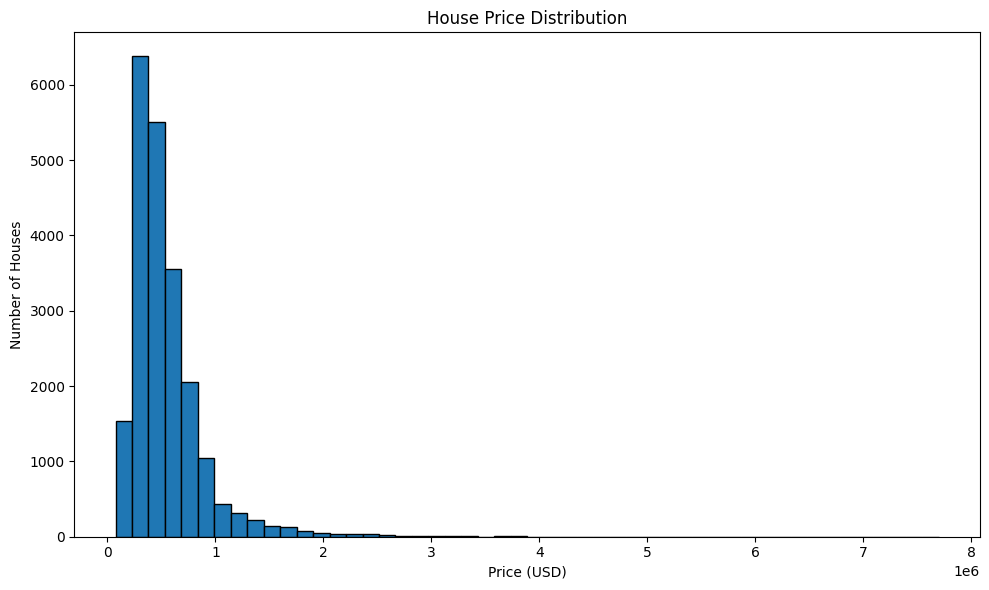

In [87]:
# Distribution of house prices
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=50, edgecolor='black')
plt.xlabel('Price (USD)')
plt.ylabel('Number of Houses')
plt.title('House Price Distribution')
plt.tight_layout()
plt.show()

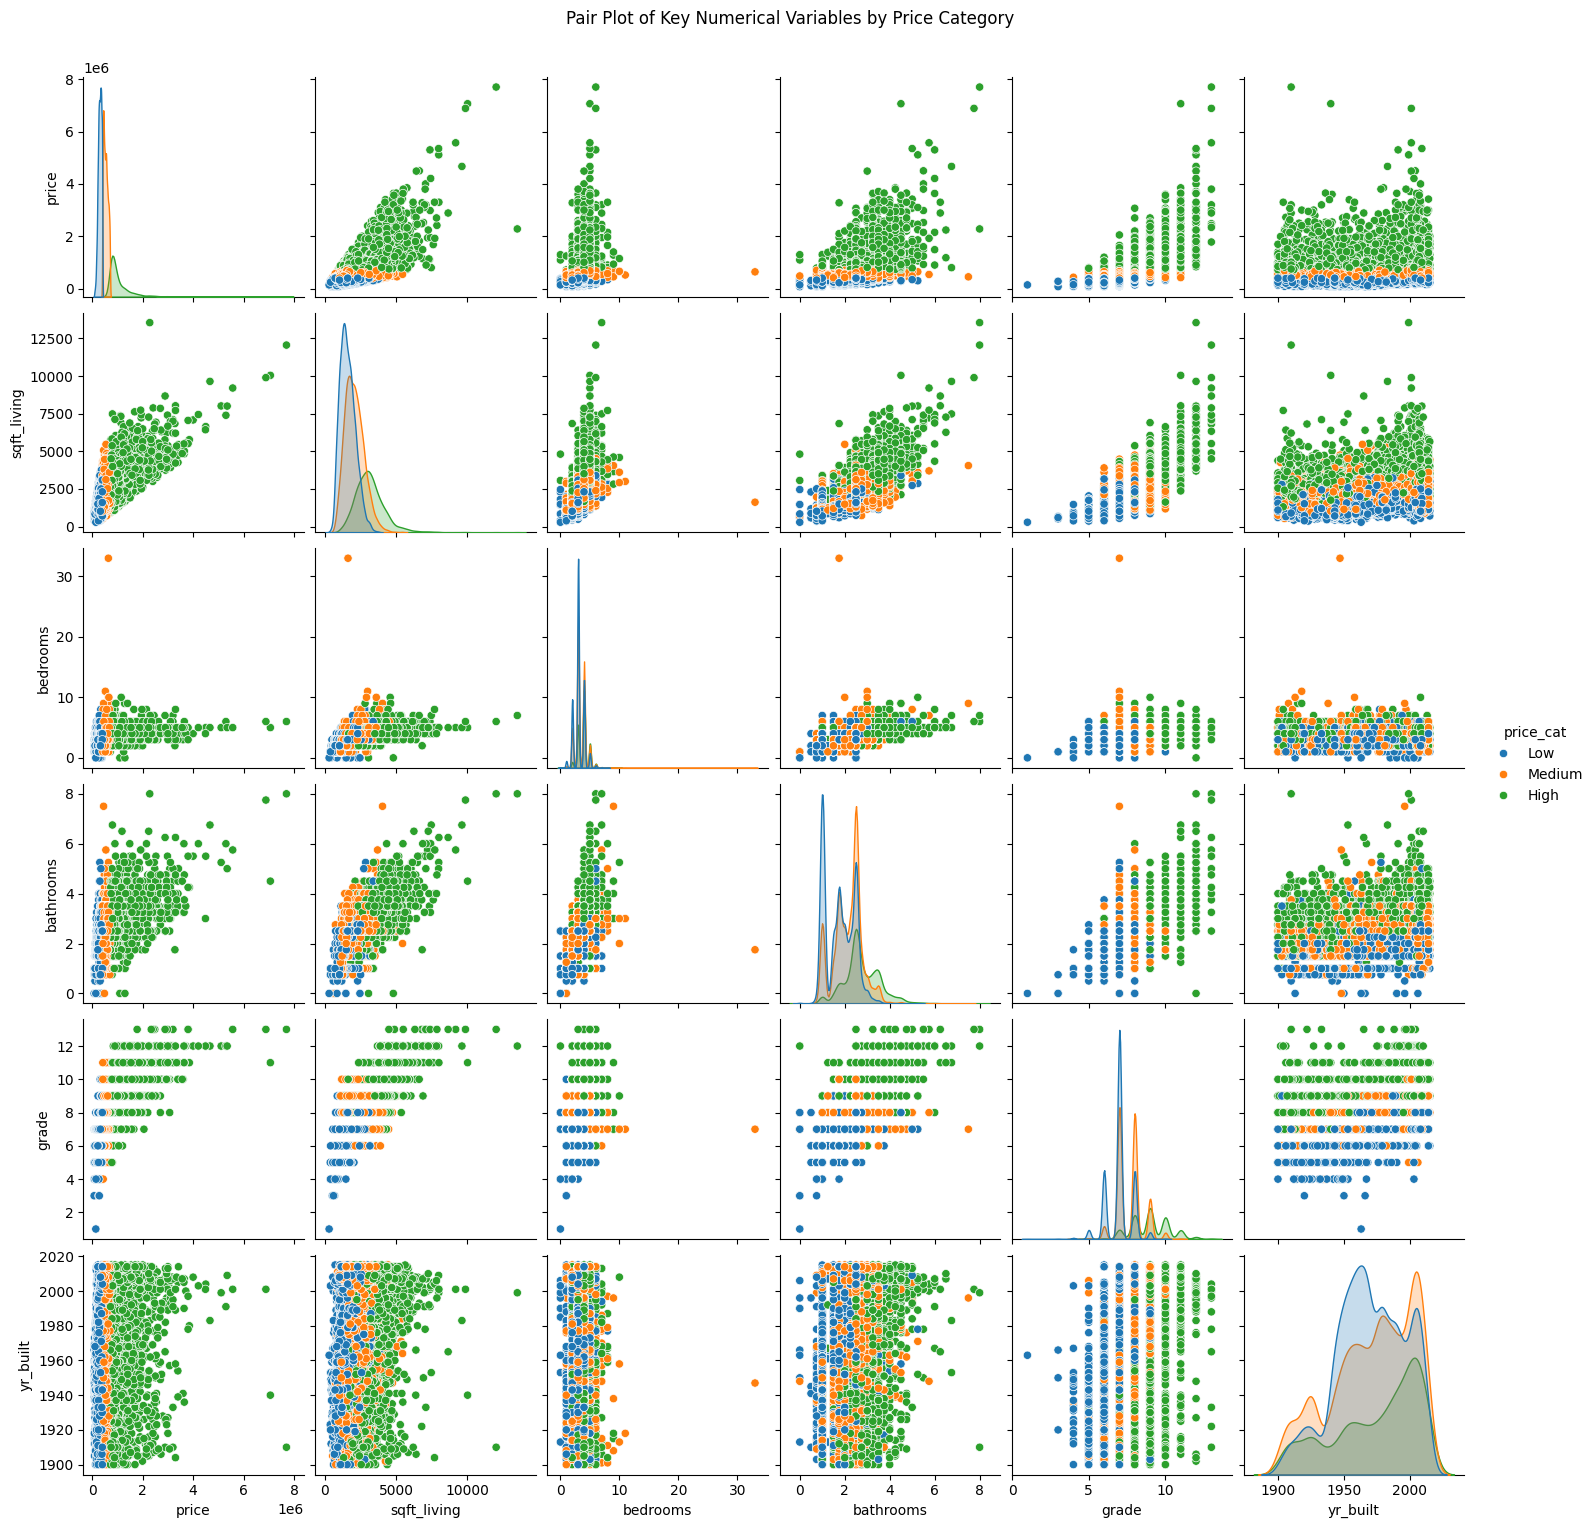

In [88]:
# Select key numerical columns relevant to price
num_cols = [
    'price',
    'sqft_living',
    'bedrooms',
    'bathrooms',
    'grade',
    'yr_built'
]

# Pair plot with price segmentation
# Create a price category for hue
df['price_cat'] = pd.cut(df['price'], bins=[0, 400000, 700000, df['price'].max()],
                         labels=['Low', 'Medium', 'High'])

sns.pairplot(
    df[num_cols + ['price_cat']],
    hue='price_cat',
    diag_kind='kde'
)

plt.suptitle('Pair Plot of Key Numerical Variables by Price Category', y=1.02)
plt.show()

df.drop(columns=['price_cat'], inplace=True)

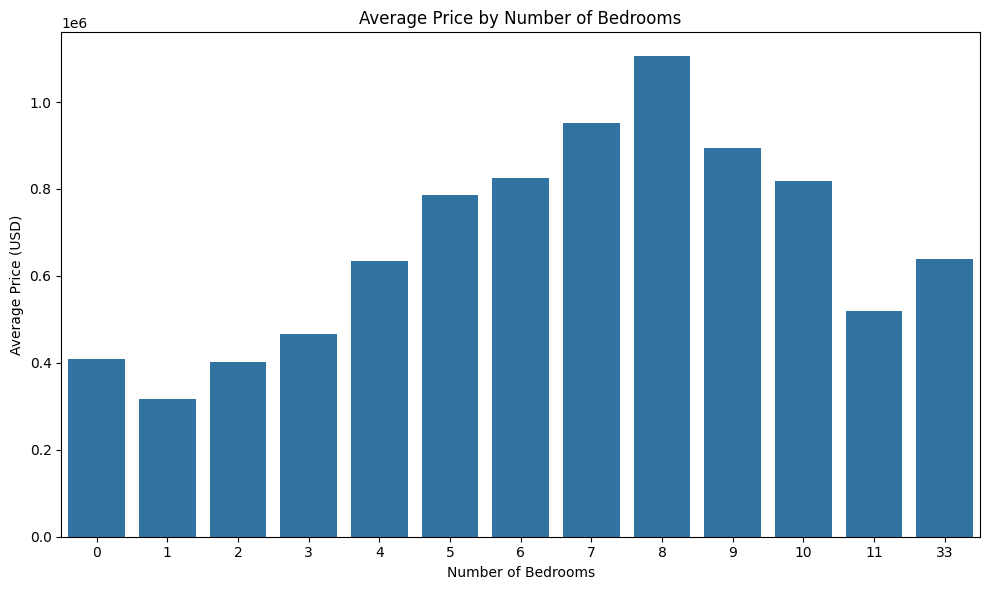

In [89]:
plt.figure(figsize=(10, 6))
plt.title('Average Price by Number of Bedrooms')

avg_price = df.groupby('bedrooms')['price'].mean().reset_index()
sns.barplot(x='bedrooms', y='price', data=avg_price)

plt.ylabel('Average Price (USD)')
plt.xlabel('Number of Bedrooms')
plt.tight_layout()
plt.show()

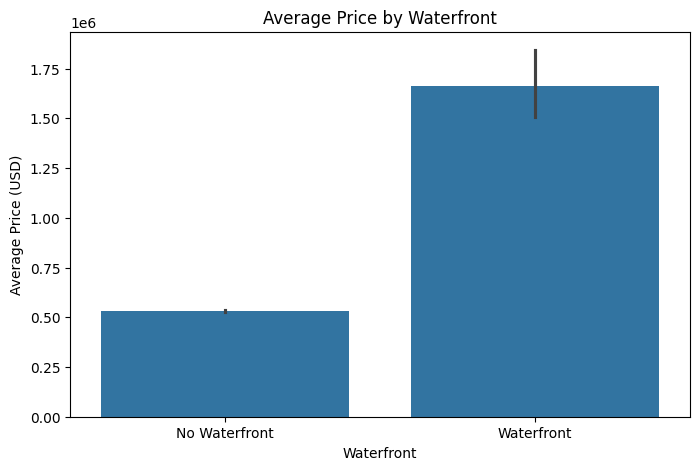

In [90]:
plt.figure(figsize=(8, 5))
plt.title('Average Price by Waterfront')

sns.barplot(
    x='waterfront',
    y='price',
    data=df
)

plt.xticks([0, 1], ['No Waterfront', 'Waterfront'])
plt.ylabel('Average Price (USD)')
plt.xlabel('Waterfront')
plt.show()

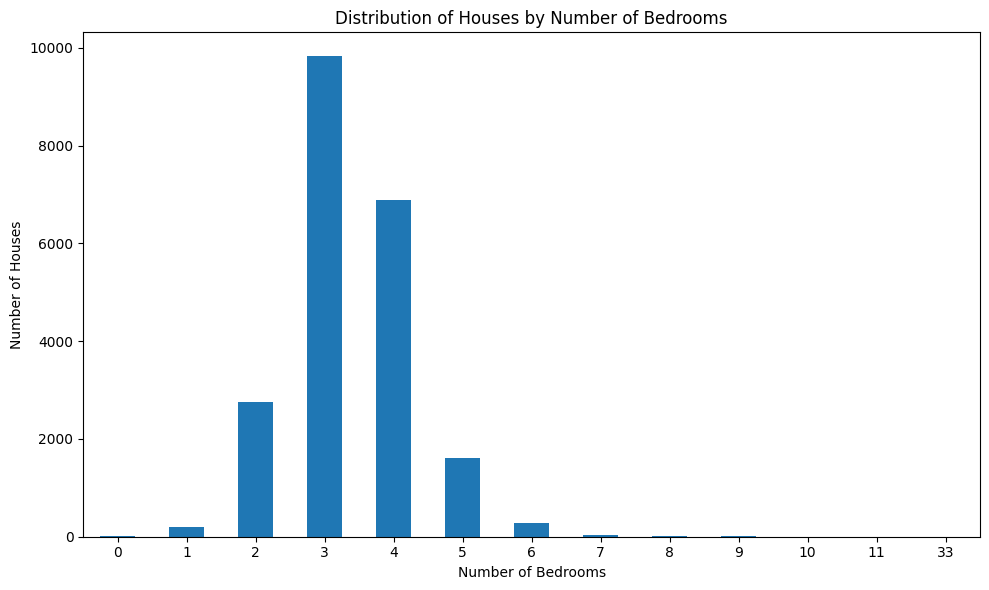

In [91]:
plt.figure(figsize=(10, 6))

bedroom_counts = df['bedrooms'].value_counts().sort_index()
bedroom_counts.plot(kind='bar')

plt.xlabel('Number of Bedrooms')
plt.ylabel('Number of Houses')
plt.title('Distribution of Houses by Number of Bedrooms')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

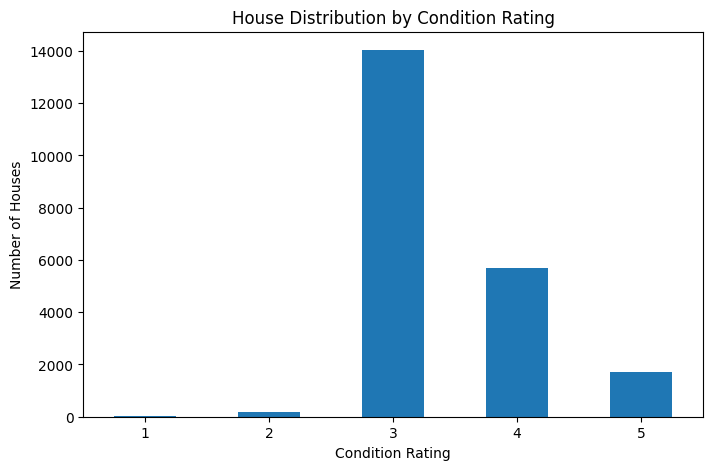

In [92]:
plt.figure(figsize=(8, 5))

condition_counts = df['condition'].value_counts().sort_index()
condition_counts.plot(kind='bar')

plt.xlabel('Condition Rating')
plt.ylabel('Number of Houses')
plt.title('House Distribution by Condition Rating')

plt.xticks(rotation=0)
plt.show()

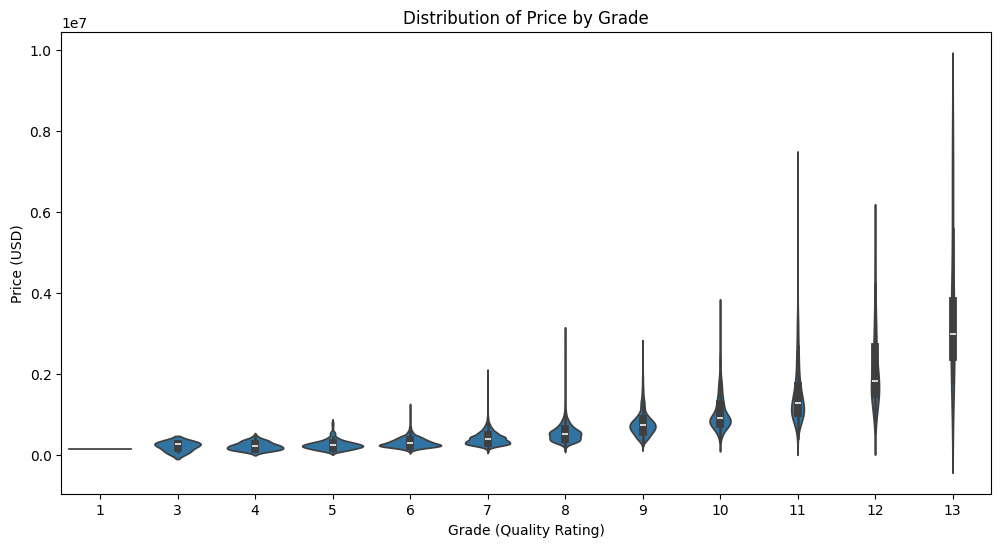

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x='grade',
    y='price'
)

plt.xlabel('Grade (Quality Rating)')
plt.ylabel('Price (USD)')
plt.title('Distribution of Price by Grade')

plt.show()

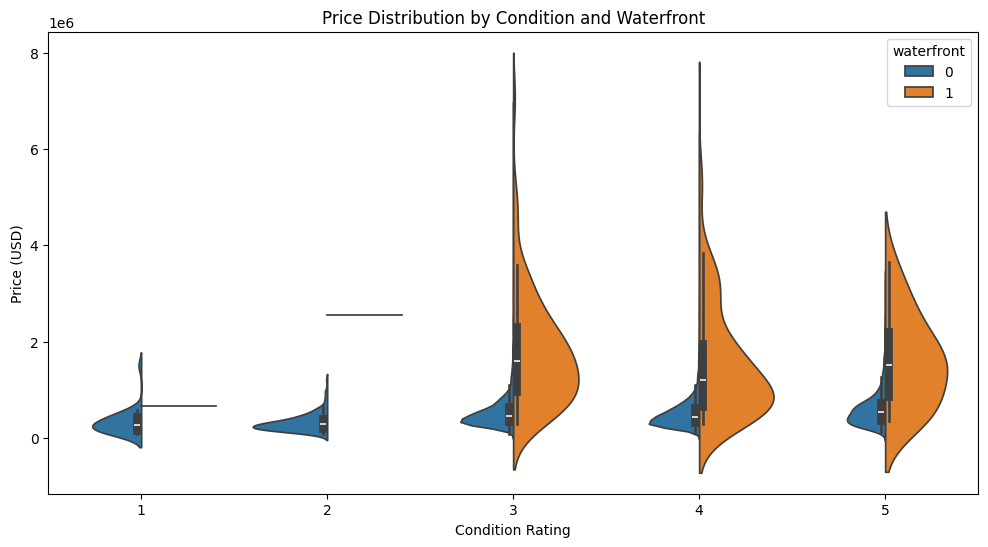

In [94]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x='condition',
    y='price',
    hue='waterfront',
    split=True
)

plt.xlabel('Condition Rating')
plt.ylabel('Price (USD)')
plt.title('Price Distribution by Condition and Waterfront')

plt.show()

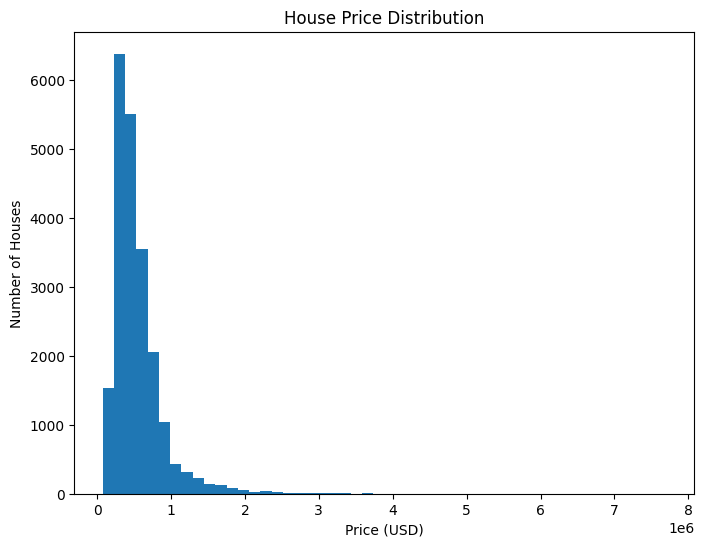

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

df['price'].plot(kind='hist', bins=50)

plt.xlabel('Price (USD)')
plt.ylabel('Number of Houses')
plt.title('House Price Distribution')

plt.xticks(rotation=0)
plt.show()

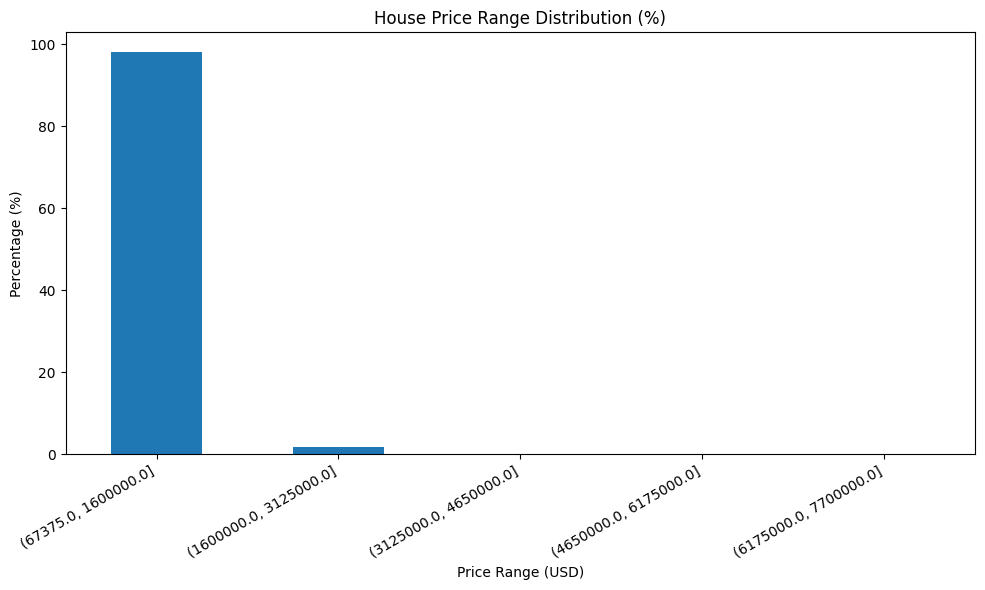

In [96]:
price_bins = pd.cut(df['price'], bins=5)
price_bin_pct = price_bins.value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(10, 6))
price_bin_pct.plot(kind='bar')

plt.xlabel('Price Range (USD)')
plt.ylabel('Percentage (%)')
plt.title('House Price Range Distribution (%)')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

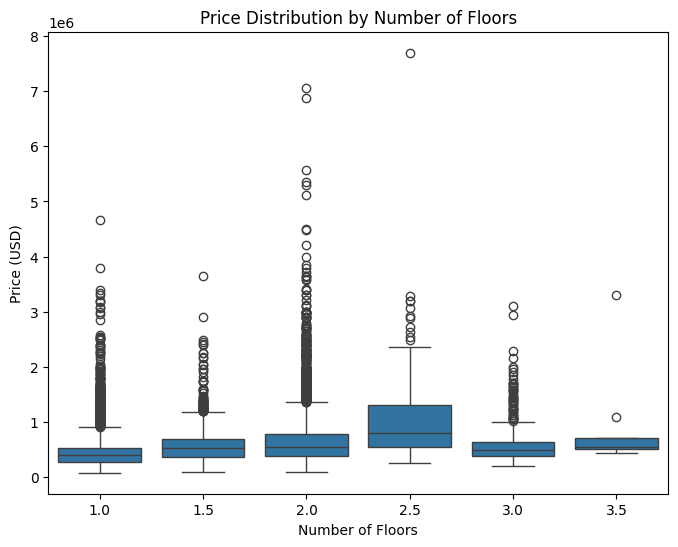

In [97]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='floors',
    y='price'
)

plt.xlabel('Number of Floors')
plt.ylabel('Price (USD)')
plt.title('Price Distribution by Number of Floors')

plt.show()

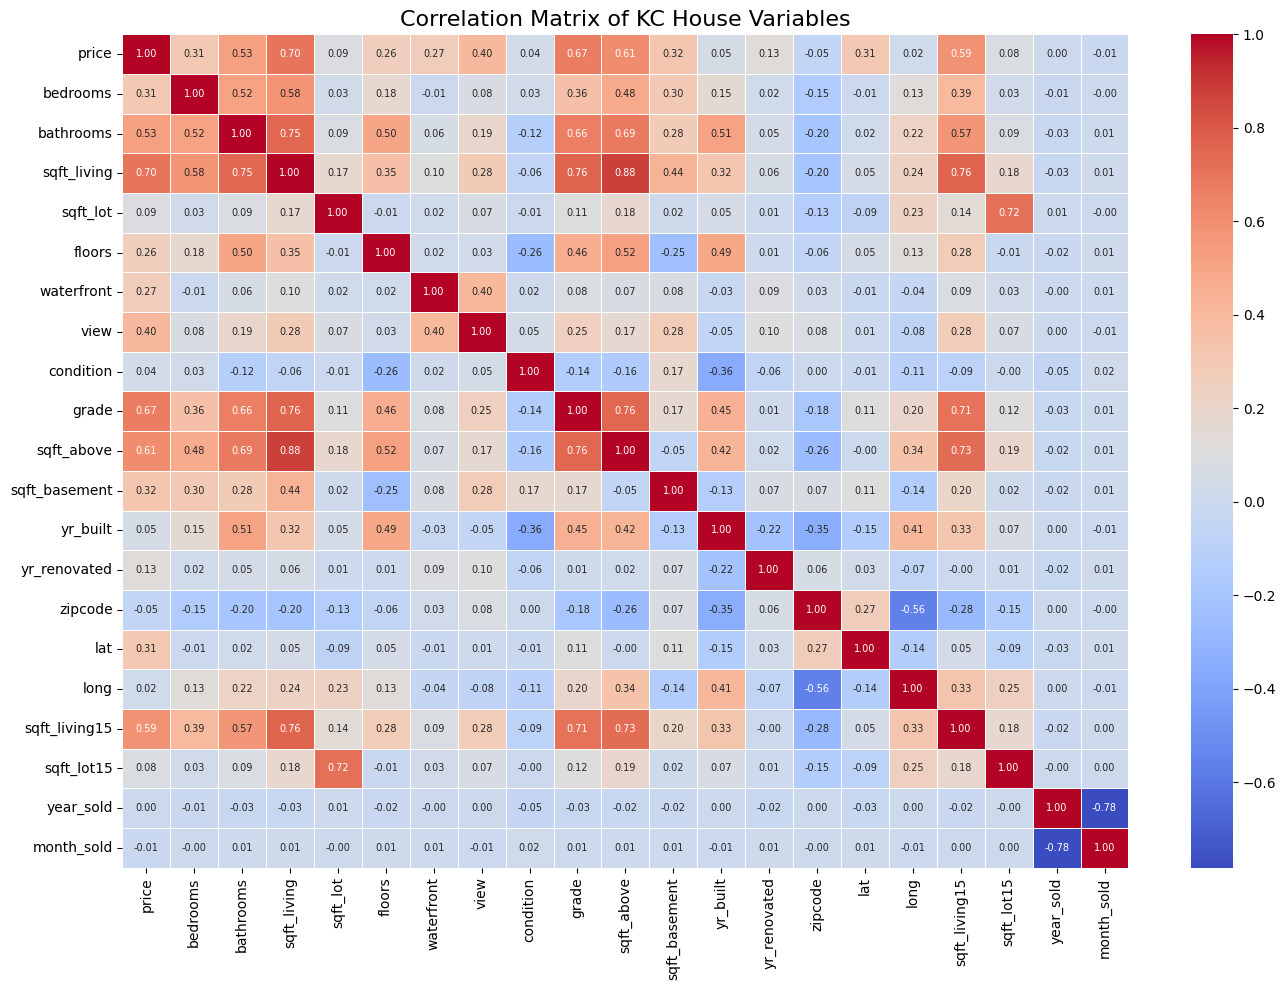

In [98]:
df2 = df.copy()

# Parse date and extract useful features
df2['date'] = pd.to_datetime(df2['date'], format='%Y%m%dT000000')
df2['year_sold'] = df2['date'].dt.year
df2['month_sold'] = df2['date'].dt.month
df2.drop(columns=['date', 'id'], inplace=True)

plt.figure(figsize=(14, 10))

# Select only numeric columns
numeric_df = df2.select_dtypes(exclude='object')

# Correlation matrix
corr = numeric_df.corr()

# Heatmap
sns.heatmap(
    corr,
    cmap='coolwarm',
    cbar=True,
    linewidths=0.5,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

plt.title('Correlation Matrix of KC House Variables', fontsize=16)
plt.tight_layout()
plt.show()

**Analysis of Correlation**- A Pearson correlation heatmap was created to measure linear relationships between features and target variable. The strongest positive correlations with price were sqft_living (r≈0.70), grade (r≈0.67), sqft_above (r≈0.61), and bathrooms (r≈0.53). These findings directly informed feature prioritization. It was also found that sqft_living and sqft_above are highly correlated with each other that is it is multicollinearity which is one of the major reasons to include Ridge Regression as one of the models.

**Key Visual Insights**- The average **price by number of bedrooms** was displayed in a bar chart and showed a general upward trend with a significant distortion from the 33 bedroom outlier.
**Average price by waterfront** status showed that waterfront properties are sold at about twice the price of non-waterfront homes which is the most influential binary predictor in the dataset.
**A violin plot of price by grade** indicates that both the median price and the spread of prices increase significantly for **grades 11 and above** which confirms that construction quality is a primary driver of luxury pricing.
**A box plot of price by number** of floors showed that multi-storey homes command a modest premium while the price bin breakdown confirmed that about **70%** of all properties are in the lowest price bracket.
Finally, the extracted month_sold feature was used to detect mild seasonal trends with spring and summer months having higher average sale prices.

# Prepare Data for Modeling

In [99]:
df.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Feature Engineering & Separate Categorical and Numerical Columns

**Feature selection** was done using a combination of **Pearson correlation analysis** and **Random Forest feature** importance scores following an initial run of the model. Instead of using a strict dimensionality reduction technique, all meaningful features were kept and ranked according to their estimated contribution to the target variable.


**The highest predictors were:** sqft_living, size of interior living space, which has the highest linear correlation with price, grade which is the rating of construction quality and design on a scale of 1 to 13; sqft_above, the square footage of the house apart from the basement, which is highly related to **sqft_living, bathrooms because houses with more bathrooms tend to be larger and more expensive**, and **waterfront, a binary variable indicating whether the house has water view access or not which has the highest premium on price among all features.**
Geographic location encoded as zipcode emerged as a crucial predictor which captures neighbourhood-level market dynamics that cannot be explained by physical features alone. The engineered features **year_sold** and **month_sold** were also kept to capture temporal patterns in the market. Moreover, the id column was dropped because it is a meaningless identifier. This replaced raw date column with extracted components.

All remaining features were included in the model training with the understanding that ensemble methods such as Random Forest would assign lower weight internally to weaker predictors.







In [100]:
# Parse date and create new time-based features
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT000000')
df['year_sold']  = df['date'].dt.year
df['month_sold'] = df['date'].dt.month
df.drop(columns=['date', 'id'], inplace=True)

# Binary/flag columns treated as categorical
df['waterfront'] = df['waterfront'].astype(str)
df['view']       = df['view'].astype(str)

# Identify categorical and numerical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numerical_columns   = df.select_dtypes(exclude=['object']).columns.tolist()

print('Categorical Columns:\n', categorical_columns)
print('\nNumerical Columns:\n', numerical_columns)

Categorical Columns:
 ['waterfront', 'view']

Numerical Columns:
 ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'year_sold', 'month_sold']


In [101]:
df[numerical_columns].head(5)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year_sold,month_sold
0,221900.0,3,1.00,1180,5650,1.0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,538000.0,3,2.25,2570,7242,2.0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,180000.0,2,1.00,770,10000,1.0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,604000.0,4,3.00,1960,5000,1.0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,510000.0,3,2.00,1680,8080,1.0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


In [102]:
df[categorical_columns].head(5)

,waterfront,view
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [103]:
target_column = 'price'

# Ensure target is excluded from predictors
predictor_numerical   = [col for col in numerical_columns   if col != target_column]
predictor_categorical = [col for col in categorical_columns if col != target_column]

print('Numerical predictors:\n',   predictor_numerical)
print('\nCategorical predictors:\n', predictor_categorical)

Numerical predictors:
 ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'year_sold', 'month_sold']

Categorical predictors:
 ['waterfront', 'view']


## Convert Categorical Columns to Numerical

Apply label encoding to categorical columns

In [104]:
label_encoder = LabelEncoder()
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

In [105]:
from sklearn.preprocessing import LabelEncoder

# Copy the dataframe to avoid modifying the original
df_encoded = df.copy()

# Encode each categorical column separately
for column in categorical_columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])

# Optional: check result
df_encoded.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year_sold,month_sold
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


Apply scaling to numerical columns

In [106]:
# Save target before scaling
y_raw = df['price'].copy()

scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
df.head(5)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year_sold,month_sold
0,-0.866717,-0.398737,-1.447464,-0.979835,-0.228321,-0.915427,0,0,-0.629187,-0.558836,...,-0.658681,-0.544898,-0.210128,1.870152,-0.352572,-0.306079,-0.943355,-0.260715,-0.690655,1.099621
1,-0.005688,-0.398737,0.175607,0.533634,-0.189885,0.936506,0,0,-0.629187,-0.558836,...,0.245141,-0.681079,4.746678,0.879568,1.161568,-0.746341,-0.432686,-0.187868,-0.690655,1.741627
2,-0.980849,-1.473959,-1.447464,-1.426254,-0.123298,-0.915427,0,0,-0.629187,-1.409587,...,-0.658681,-1.293892,-0.210128,-0.933388,1.283537,-0.135655,1.070140,-0.172375,1.447901,-1.468403
3,0.174090,0.676485,1.149449,-0.130550,-0.244014,-0.915427,0,0,2.444294,-0.558836,...,1.397515,-0.204446,-0.210128,1.085160,-0.283288,-1.271816,-0.914174,-0.284522,-0.690655,1.741627
4,-0.081958,-0.398737,-0.149007,-0.435422,-0.169653,-0.915427,0,0,-0.629187,0.291916,...,-0.658681,0.544548,-0.210128,-0.073636,0.409550,1.199335,-0.272190,-0.192849,1.447901,-1.468403


# Data Splitting

Split features (data) and target variable

In [107]:
# Features (all columns except the target)
X = df.drop(columns=['price'])

# Target variable (use raw unscaled prices for interpretability)
y = y_raw

# Optional: check shapes
print('X shape:', X.shape)
print('y shape:', y.shape)
print('Target stats:\n', y.describe())

X shape: (21613, 20)
y shape: (21613,)
Target stats:
 count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64


In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [109]:
print('train features shape: ', X_train.shape)
print('train target   shape: ', y_train.shape)
print('__________\n')
print('test  features shape: ', X_test.shape)
print('test  target   shape: ', y_test.shape)

train features shape:  (17290, 20)
train target   shape:  (17290,)
__________

test  features shape:  (4323, 20)
test  target   shape:  (4323,)


# Modeling

## Linear Regression

•	**Linear Regression**- Linear Regression is the baseline foundation. It assumes a linear or straight-line relationship between each feature and the target price. Each predictor is given a coefficient weight. The model is quick to train, and the coefficients are directly interpretable — **for example, a positive coefficient on sqft_living tells us that larger homes sell for higher prices.** However, Linear Regression assumes a strict linear relationship between inputs and output. This is too simplistic for housing data, where there are diminishing returns, interaction effects, and neighborhood dynamics.

### Training

In [110]:
LR = LinearRegression()
LR.fit(X_train, y_train)

LinearRegression()

### Evaluation

In [111]:
y_pred = LR.predict(X_test)
y_pred

array([ 454653.20563208,  744707.0502238 , 1228558.69045768, ...,
        414950.48252975,  613419.4193529 ,  436763.49311079])

In [112]:
y_test

,price
735,365000.0
2830,865000.0
4106,1038000.0
16218,1490000.0
19964,711000.0
...,...
13674,338000.0
20377,673000.0
8805,285000.0
10168,605000.0


In [113]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f'RMSE : {rmse:,.2f}')
print(f'MAE  : {mae:,.2f}')
print(f'R²   : {r2:.4f}')

RMSE : 212,036.17
MAE  : 126,963.21
R²   : 0.7026


In [114]:
LR.coef_

array([-32058.58755212,  34355.89820368,  80793.67141977,   3569.51630804,
         4112.09345535, 562962.62077578,  53331.08688737,  16867.71051361,
       111419.09425565,  75365.27896322,  26650.63182385, -78596.08345967,
         8671.12679912, -29577.25056298,  82920.88022166, -27427.26718414,
        14688.63462759,  -8945.34882966,  17351.37593979,   4065.55251787])

In [115]:
LR.intercept_

np.float64(522752.8013191689)

Save the results

In [116]:
results = pd.DataFrame(columns=['Model Name', 'RMSE', 'MAE', 'R2 Score'])

### Residual Plot

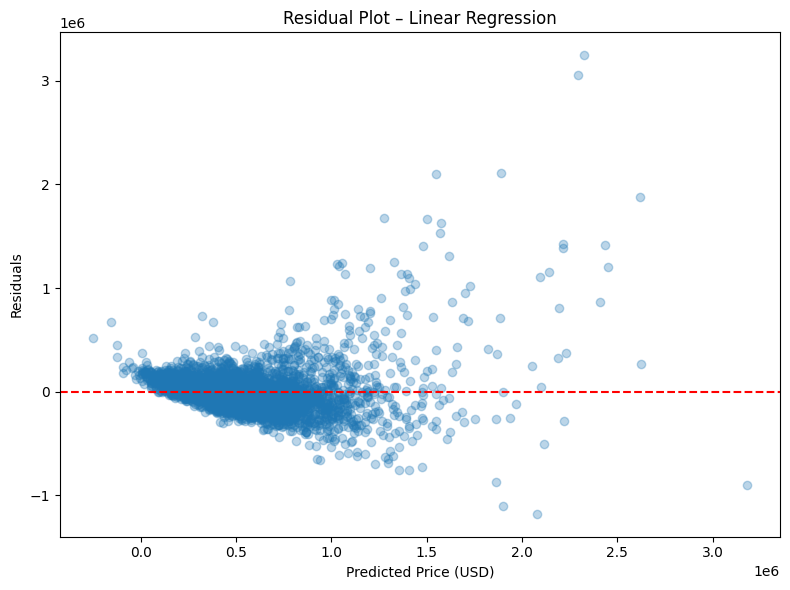

In [117]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residuals')
plt.title('Residual Plot – Linear Regression')
plt.tight_layout()
plt.show()

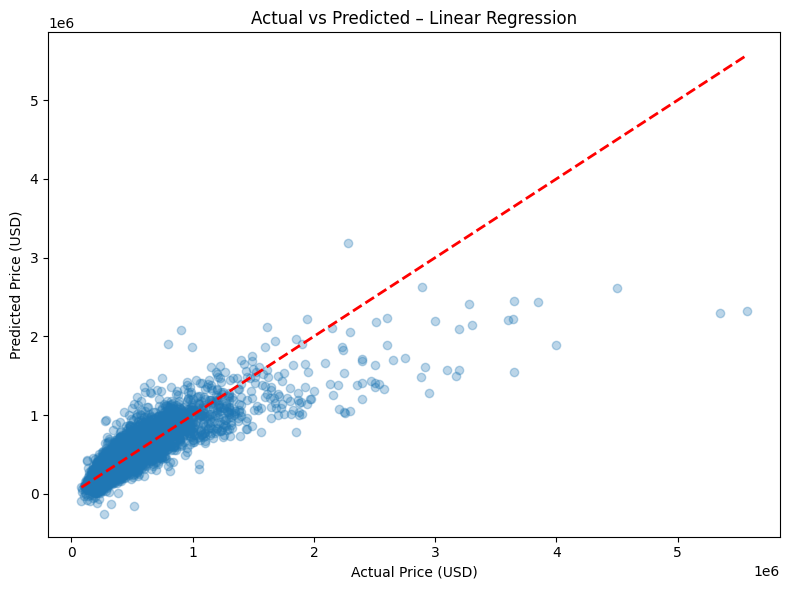

In [118]:
# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted – Linear Regression')
plt.tight_layout()
plt.show()

In [119]:
model_result = ['Linear Regression',
                np.sqrt(mean_squared_error(y_test, y_pred)),
                mean_absolute_error(y_test, y_pred),
                r2_score(y_test, y_pred)]
results.loc[len(results)] = model_result
results

,Model Name,RMSE,MAE,R2 Score
0,Linear Regression,212036.16538,126963.208633,0.702604


## Random Forest Regressor

**Random Forest Regressor** trains 100 decision trees, each on a random bootstrap sample with a random feature subset at every split, with the final prediction being the average across all trees.

This approach naturally handles **non-linear relationships** and **feature interactions**, is robust to outliers, provides built-in feature importance scores, and reduces overfitting through averaging. It was selected as the best-performing model based on its highest R² and lowest error metrics.

### Model Training

In [120]:
RF = RandomForestRegressor(n_estimators=100, criterion='squared_error', random_state=42)
RF.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

### Evaluation

In [121]:
y_pred = RF.predict(X_test)
y_pred

array([ 379890.4 ,  875449.04, 1115917.8 , ...,  286280.13,  585972.3 ,
        344289.19])

In [122]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f'RMSE : {rmse:,.2f}')
print(f'MAE  : {mae:,.2f}')
print(f'R²   : {r2:.4f}')

RMSE : 150,126.33
MAE  : 72,905.08
R²   : 0.8509


### Residual Plot

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residuals')
plt.title('Residual Plot – Random Forest Regressor')
plt.tight_layout()
plt.show()

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted – Random Forest Regressor')
plt.tight_layout()
plt.show()

### Save Results

In [ ]:
model_result = ['Random Forest',
                np.sqrt(mean_squared_error(y_test, y_pred)),
                mean_absolute_error(y_test, y_pred),
                r2_score(y_test, y_pred)]
results.loc[len(results)] = model_result
results

## Ridge Regression

**Ridge Regression** adds an L2 penalty to the ordinary least squares objective, shrinking large coefficients toward zero. Given the high correlation between **sqft_living** and **sqft_above**, ordinary Linear Regression can produce unstable coefficients under this multicollinearity. Ridge spreads weight more evenly among correlated features, producing a more stable and generalisable model. An alpha of 1.0 was used with a maximum of 1,000 iterations

### Model Training

In [ ]:
ridge_regression = Ridge(alpha=1.0, fit_intercept=True, max_iter=1000)
ridge_regression.fit(X_train, y_train)

### Model Evaluation

In [ ]:
y_pred = ridge_regression.predict(X_test)
y_pred

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f'RMSE : {rmse:,.2f}')
print(f'MAE  : {mae:,.2f}')
print(f'R²   : {r2:.4f}')

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residuals')
plt.title('Residual Plot – Ridge Regression')
plt.tight_layout()
plt.show()

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted – Ridge Regression')
plt.tight_layout()
plt.show()

Save results

In [ ]:
model_result = ['Ridge Regression',
                np.sqrt(mean_squared_error(y_test, y_pred)),
                mean_absolute_error(y_test, y_pred),
                r2_score(y_test, y_pred)]
results.loc[len(results)] = model_result
results

## Linear Support Vector Regressor (LinearSVR)

**Linear Support Vector Regressor** maximises a margin (epsilon-tube) around the regression hyperplane, penalising only predictions that fall outside the tube. This makes it more robust to individual outliers than least-squares methods. **A regularisation parameter C of 0.9 and a maximum of 2,000 iterations were used.** Like the other linear methods, LinearSVR cannot model the non-linear interactions inherent in real-estate pricing.

### Model Training

In [ ]:
LSVR = LinearSVR(C=0.9, dual=True, max_iter=2000)
LSVR.fit(X_train, y_train)

### Model Evaluation

In [ ]:
y_pred = LSVR.predict(X_test)
y_pred

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f'RMSE : {rmse:,.2f}')
print(f'MAE  : {mae:,.2f}')
print(f'R²   : {r2:.4f}')

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residuals')
plt.title('Residual Plot – Linear SVR')
plt.tight_layout()
plt.show()

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted – Linear SVR')
plt.tight_layout()
plt.show()

In [ ]:
model_result = ['Linear SVR',
                np.sqrt(mean_squared_error(y_test, y_pred)),
                mean_absolute_error(y_test, y_pred),
                r2_score(y_test, y_pred)]
results.loc[len(results)] = model_result
results

## CNN (Convolutional Neural Network)

**A Convolutional Neural Network** was included as an experimental model. CNNs are designed for spatially structured inputs, so each sample's feature vector was reshaped into a 1xF "image", allowing the convolutional layer to detect local patterns across adjacent features.

The architecture consists of a Conv2D layer with 2 filters and a 1x3 kernel using ReLU activation and same padding, followed by MaxPooling2D, a Flatten layer, a Dense layer with 64 units and ReLU activation, a Dropout layer with a rate of 0.1 for regularisation, and a final linear Dense output.

**The model was trained with the Adam optimiser using mean squared error as the loss function for 20 epochs, with a 64/16/20 train/validation/test split.**
In practice, tree-based ensembles typically outperform CNNs on tabular data; this model demonstrates architectural flexibility rather than claiming superiority.


### Convert data to image format
CNN mainly works with images, so we convert our numerical data into image shape.

In [ ]:
# Normalize Data
X_norm = df.drop(columns=['price'])
X_normalized = (X_norm - X_norm.min()) / (X_norm.max() - X_norm.min())

X_array = X_normalized.values

N_samples, N_features = X_array.shape
height   = 1
width    = N_features
channels = 1
X_reshaped = X_array.reshape(N_samples, height, width, channels)

In [ ]:
img = X_reshaped[5]
plt.imshow(img)
plt.title('Sample House Feature Row as Image')
plt.show()

### Split Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_raw, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

In [ ]:
print('train features shape: ', X_train.shape)
print('train target   shape: ', y_train.shape)
print('__________\n')
print('valid  features shape: ', X_valid.shape)
print('valid  target   shape: ', y_valid.shape)
print('__________\n')
print('test  features shape: ', X_test.shape)
print('test  target   shape: ', y_test.shape)

In [ ]:
model = Sequential([
    Conv2D(2, (1, 3), activation='relu', input_shape=(height, width, channels), padding='same'),
    MaxPooling2D((1, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(1)   # Linear output for regression
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

In [ ]:
# Train Model
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_valid, y_valid)
)

### Evaluate Model

In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test)
print('Test MAE:', test_mae)

In [ ]:
y_pred_cnn = model.predict(X_test).flatten()
print(y_pred_cnn.shape)
y_pred_cnn[:5]

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_cnn))
mae  = mean_absolute_error(y_test, y_pred_cnn)
r2   = r2_score(y_test, y_pred_cnn)

print(f'CNN – RMSE : {rmse:,.2f}')
print(f'CNN – MAE  : {mae:,.2f}')
print(f'CNN – R²   : {r2:.4f}')

In [ ]:
# Actual vs Predicted – CNN
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_cnn, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted – CNN')
plt.tight_layout()
plt.show()

In [ ]:
residuals_cnn = y_test.values - y_pred_cnn

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_cnn, residuals_cnn, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residuals')
plt.title('Residual Plot – CNN')
plt.tight_layout()
plt.show()

In [ ]:
model_result = ['CNN',
                np.sqrt(mean_squared_error(y_test, y_pred_cnn)),
                mean_absolute_error(y_test, y_pred_cnn),
                r2_score(y_test, y_pred_cnn)]
results.loc[len(results)] = model_result
results

In [ ]:
model.save('cnn_house_price_model.keras')

# Evaluation and Comparison

In [ ]:
results

### R² Score Comparison

In [ ]:
import seaborn as sns
plt.subplots(figsize=(7, 5))
sns.barplot(x='Model Name', y='R2 Score', data=results)
plt.xticks(rotation=30, ha='right')
plt.title('Models Testing & Evaluation – R² Score Comparison')
plt.tight_layout()
plt.show()

### RMSE Comparison

In [ ]:
plt.subplots(figsize=(7, 5))
sns.barplot(x='Model Name', y='RMSE', data=results)
plt.xticks(rotation=30, ha='right')
plt.title('Models Testing & Evaluation – RMSE Comparison')
plt.tight_layout()
plt.show()

### Inference on New Data using Saved CNN Model

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import load_model

# Load trained CNN
loaded_model = load_model('cnn_house_price_model.keras')

# Load new data
new_data_df = pd.read_csv('kc_house_data.csv')

# Columns used during training (EXACT ORDER, excluding 'price')
training_columns = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'waterfront', 'view', 'condition', 'grade', 'sqft_above',
    'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat',
    'long', 'sqft_living15', 'sqft_lot15'
]

# Feature engineering
new_data_df['date'] = pd.to_datetime(new_data_df['date'], format='%Y%m%dT000000')
new_data_df['year_sold']  = new_data_df['date'].dt.year
new_data_df['month_sold'] = new_data_df['date'].dt.month
new_data_df['waterfront'] = new_data_df['waterfront'].astype(str)
new_data_df['view']       = new_data_df['view'].astype(str)

training_columns_ext = training_columns + ['year_sold', 'month_sold']
new_data_df = new_data_df[training_columns_ext]

# Categorical and numerical
categorical_cols = ['waterfront', 'view']
numerical_cols   = [c for c in training_columns_ext if c not in categorical_cols]

# Encode
for col in categorical_cols:
    le = LabelEncoder()
    new_data_df[col] = le.fit_transform(new_data_df[col])

# Normalize for CNN
X_new = new_data_df.values.astype(float)
X_new_norm = (X_new - X_new.min(axis=0)) / (X_new.max(axis=0) - X_new.min(axis=0) + 1e-8)

N, F = X_new_norm.shape
X_new_reshaped = X_new_norm.reshape(N, 1, F, 1)

# Predict
predictions = loaded_model.predict(X_new_reshaped).flatten()

print('Predicted House Prices (USD):')
print(predictions[:10])

**Models were evaluated on three metrics: **RMSE (root mean squared error in USD), MAE (mean absolute error in USD), and R² (the proportion of price variance explained by the model, where 1.0 is perfect).

**Random Forest achieved the highest R² and the lowest RMSE and MAE among all five models**, confirming that the ensemble approach best captures the non-linear structure of the King County housing market.

T**he linear models (Linear Regression, Ridge, and LinearSVR) produced similar performance to one another**, reflecting their shared inability to capture non-linear relationships.

**The CNN fell between the linear models and Random Forest**, showing some capacity to learn patterns but not matching the ensemble's efficiency on this tabular dataset.